In [22]:
import glob
import os

import pandas as pd
import numpy as np

import torch
from model import LightningWBoson
import train

from matplotlib import pyplot as plt
from plottingtool import plot_1d_hist, plot_2d_hist, plot_2d_res_hist

import mplhep as hep
hep.style.use("ATLAS")

In [23]:
fold  = "fold0"
# ckpt_files = glob.glob(f"./hww_pcres_regressor_kfold/{fold}/version_0/checkpoints/*.ckpt")
ckpt_files = glob.glob(f"./hww_pcres_regressor_nofold/logs/version_0/checkpoints/*.ckpt")
print(f"Found checkpoint files: {ckpt_files}")
if not ckpt_files: 
    raise FileNotFoundError(f"No checkpoint files found in checkpoints")
ckpt_path = ckpt_files[0]  # Use the first checkpoint found
print(f"Using checkpoint: {ckpt_path}")

Found checkpoint files: ['./hww_pcres_regressor_nofold/logs/version_0/checkpoints/reg-epoch=367-val_loss=16.19.ckpt']
Using checkpoint: ./hww_pcres_regressor_nofold/logs/version_0/checkpoints/reg-epoch=367-val_loss=16.19.ckpt


In [24]:
# Retrieve datamodule used in training
# train = two_fold_train
dm = train.main(train=False)
# Load model from checkpoint
model = LightningWBoson.load_from_checkpoint(ckpt_path, weights_only=False, strict=False)
model.eval() # used to inference -> not for training phase

# Set up the data module (prepare data and setup splits)
dm.setup(stage="test")  # Ensure test dataset is ready
# Get the test dataloader
test_loader = dm.test_dataloader()

# Run inference
train_features = np.zeros([0, dm.X.shape[1]])
predictions = np.zeros([0, dm.Y.shape[1]-2]) # without including W0 and W1 mass
true_labels = np.zeros([0, dm.Y.shape[1]])
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

with torch.no_grad():  # Disable gradient computation for inference
    for batch in test_loader:
        # Assuming batch contains inputs and targets
        inputs, targets = batch
        # print(f"Inputs shape: {inputs.shape}, Targets shape: {targets.shape}")
        inputs = inputs.to(device)
        targets = targets.to(device)
        
        # Forward pass
        outputs = model(inputs)
        
        # Store predictions and true labels
        train_features = np.append(train_features, inputs.cpu().numpy(), axis=0)
        predictions = np.append(predictions, outputs.cpu().numpy(), axis=0)
        true_labels = np.append(true_labels, targets.cpu().numpy(), axis=0)

Evaluation mode, loading checkpoints...
Training objects shape: (376985, 23)
Target objects shape: (376985, 10)
Removed 0 rows with NaN or infinite values
Using 6 num of workers in data loading.
Using random split (val_frac / test_frac)
Loading model from checkpoint for evaluation... return datamodule
Using 4 SA blocks.
Using random split (val_frac / test_frac)


In [25]:
true_lep0_px = train_features[:, 0]
true_lep0_py = train_features[:, 1]
true_lep0_pz = train_features[:, 2]
true_lep0_energy = train_features[:, 3]
true_lep1_px = train_features[:, 4]
true_lep1_py = train_features[:, 5]
true_lep1_pz = train_features[:, 6]
true_lep1_energy = train_features[:, 7]
true_met_px = train_features[:, 20]
true_met_py = train_features[:, 21]

In [26]:
pred_w0_px = predictions[..., 0]
pred_w0_py = predictions[..., 1]
pred_w0_pz = predictions[..., 2]
pred_w0_energy = np.expm1(predictions[..., 3])
pred_w1_px = predictions[..., 4]
pred_w1_py = predictions[..., 5]
pred_w1_pz = predictions[..., 6]
pred_w1_energy = np.expm1(predictions[..., 7])
pred_w0_mass_2 = pred_w0_energy**2 - (pred_w0_px**2 + pred_w0_py**2 + pred_w0_pz**2)
pred_w1_mass_2 = pred_w1_energy**2 - (pred_w1_px**2 + pred_w1_py**2 + pred_w1_pz**2)

true_w0_px = true_labels[..., 0]
true_w0_py = true_labels[..., 1]
true_w0_pz = true_labels[..., 2]
true_w0_energy = np.expm1(true_labels[..., 3])
true_w1_px = true_labels[..., 4]
true_w1_py = true_labels[..., 5]
true_w1_pz = true_labels[..., 6]
true_w1_energy = np.expm1(true_labels[..., 7])
true_w0_mass_2 = true_labels[..., 8] ** 2
true_w1_mass_2 = true_labels[..., 9] ** 2

/tmp/ipykernel_335748/2513785030.py:10: RuntimeWarning: invalid value encountered in sqrt
  true_higgs_mass = np.sqrt(true_higgs_energy**2 - (true_higgs_px**2 + true_higgs_py**2 + true_higgs_pz**2))


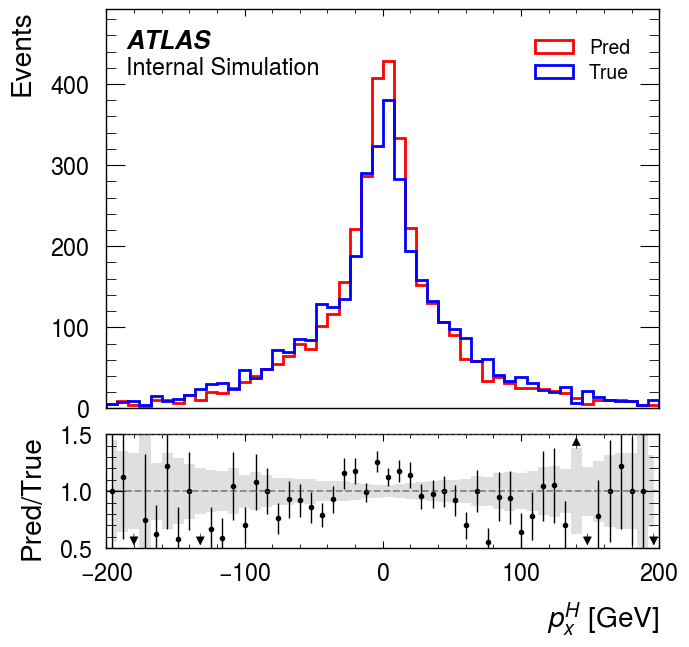

Rel err < 20%: 26.32 %


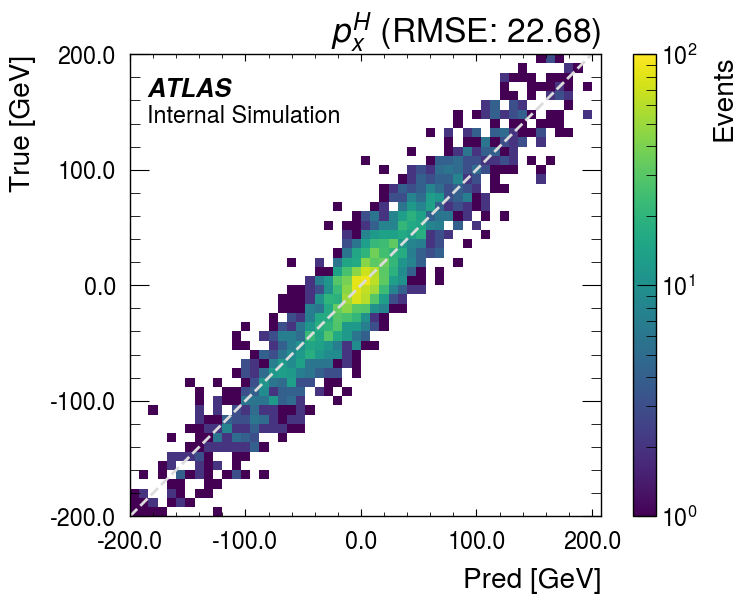

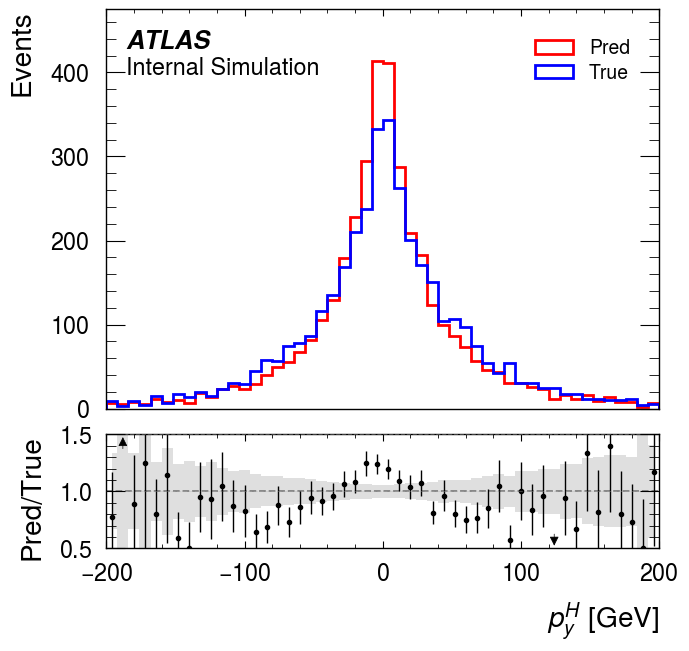

Rel err < 20%: 27.17 %


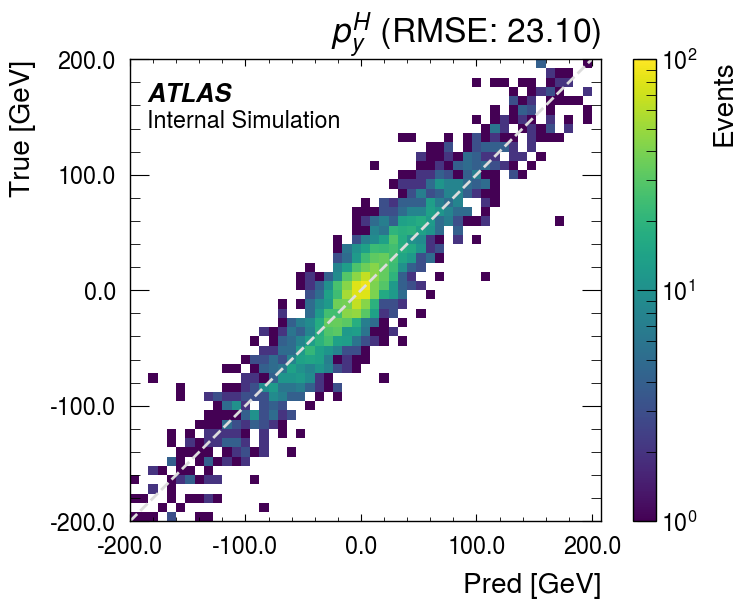

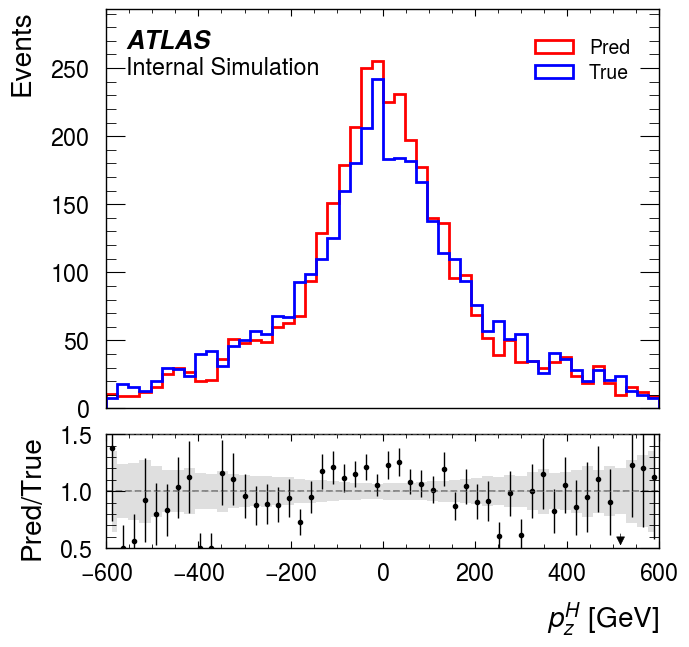

Rel err < 20%: 31.52 %


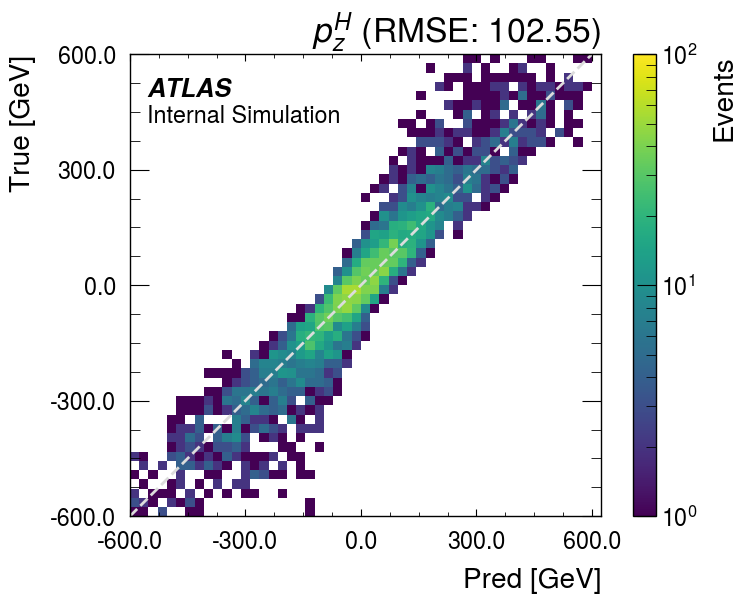

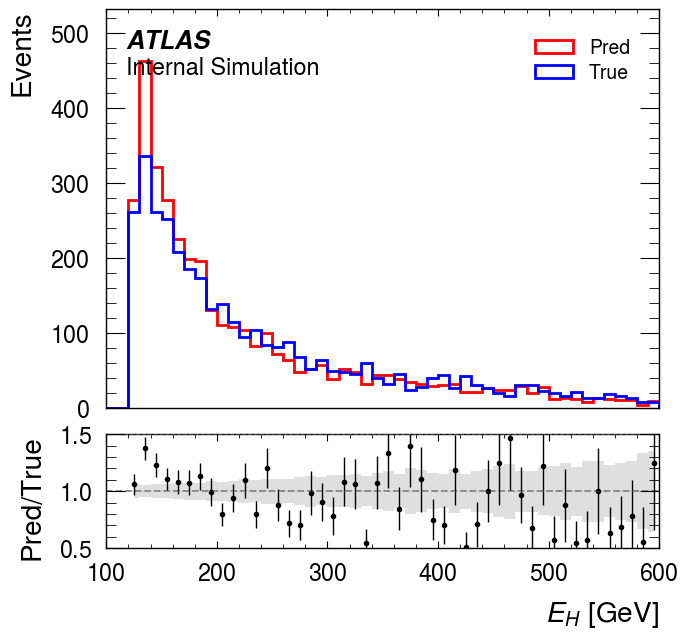

Rel err < 20%: 74.71 %


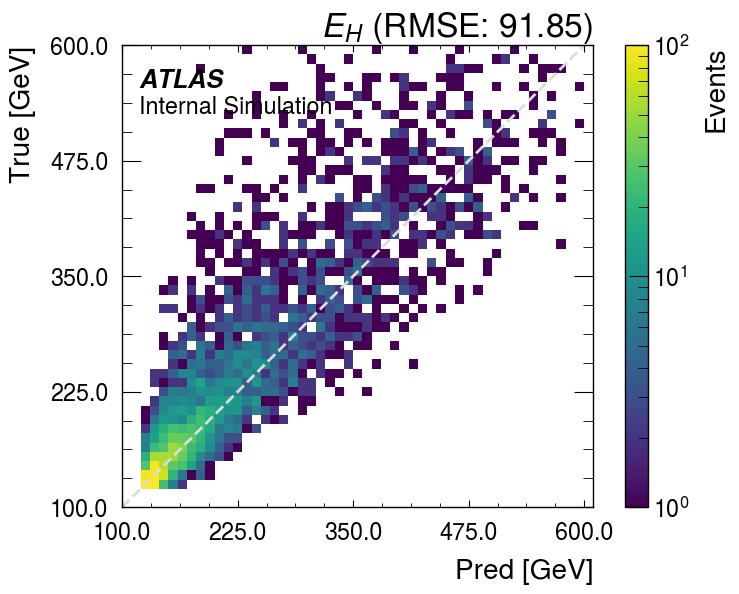

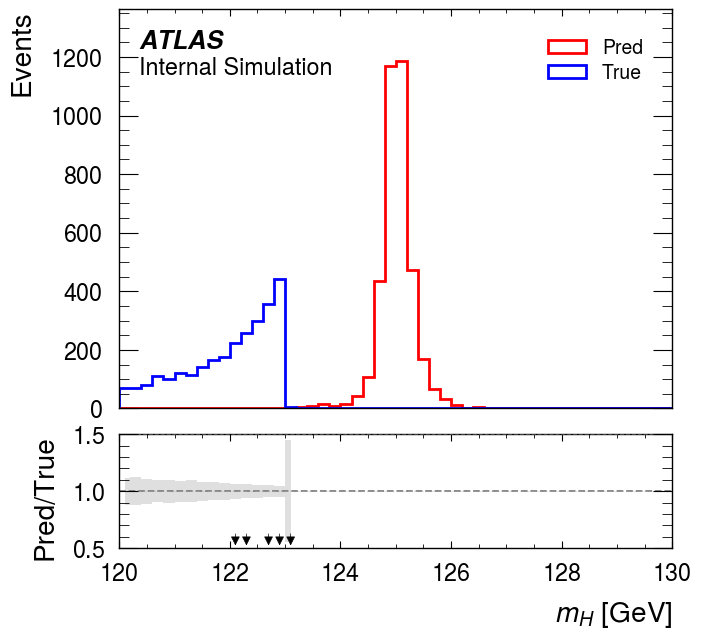

Mean predicted Higgs mass: 125.01 GeV, Std: 0.35 GeV
Rel err < 20%: 99.68 %


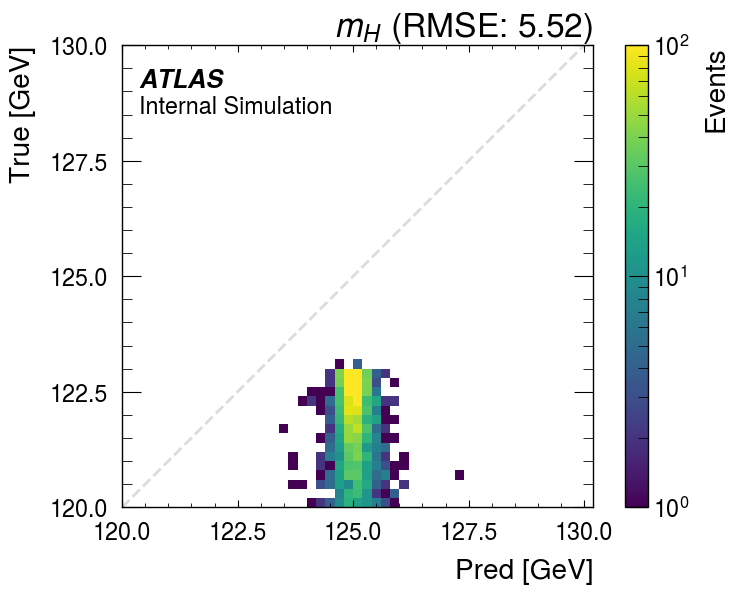

In [27]:
pred_higgs_px = pred_w0_px + pred_w1_px
pred_higgs_py = pred_w0_py + pred_w1_py
pred_higgs_pz = pred_w0_pz + pred_w1_pz
pred_higgs_energy = pred_w0_energy + pred_w1_energy
pred_higgs_mass = np.sqrt(pred_higgs_energy**2 - (pred_higgs_px**2 + pred_higgs_py**2 + pred_higgs_pz**2))
true_higgs_px = true_w0_px + true_w1_px
true_higgs_py = true_w0_py + true_w1_py
true_higgs_pz = true_w0_pz + true_w1_pz
true_higgs_energy = true_w0_energy + true_w1_energy
true_higgs_mass = np.sqrt(true_higgs_energy**2 - (true_higgs_px**2 + true_higgs_py**2 + true_higgs_pz**2))


plot_1d_hist(pred_higgs_px, true_higgs_px, "$p_x^{H}$", bins_edges=np.linspace(-200, 200, 51), unit="GeV")
plot_2d_hist(pred_higgs_px, true_higgs_px, "$p_x^{H}$", bins_edges=np.linspace(-200, 200, 51), log=True, unit="GeV")
plot_1d_hist(pred_higgs_py, true_higgs_py, "$p_y^{H}$", bins_edges=np.linspace(-200, 200, 51), unit="GeV")
plot_2d_hist(pred_higgs_py, true_higgs_py, "$p_y^{H}$", bins_edges=np.linspace(-200, 200, 51), log=True, unit="GeV")
plot_1d_hist(pred_higgs_pz, true_higgs_pz, "$p_z^{H}$", bins_edges=np.linspace(-600, 600, 51), unit="GeV")
plot_2d_hist(pred_higgs_pz, true_higgs_pz, "$p_z^{H}$", bins_edges=np.linspace(-600, 600, 51), log=True, unit="GeV")
plot_1d_hist(pred_higgs_energy, true_higgs_energy, "$E_H$", bins_edges=np.linspace(100, 600, 51), unit="GeV")
plot_2d_hist(pred_higgs_energy, true_higgs_energy, "$E_H$", bins_edges=np.linspace(100, 600, 51), log=True, unit="GeV")
plot_1d_hist(pred_higgs_mass, true_higgs_mass, "$m_H$", bins_edges=np.linspace(120, 130, 51), unit="GeV")
print(f"Mean predicted Higgs mass: {pred_higgs_mass.mean():.2f} GeV, Std: {pred_higgs_mass.std():.2f} GeV")
plot_2d_hist(pred_higgs_mass, true_higgs_mass, "$m_H$", bins_edges=np.linspace(120, 130, 51), log=True, unit="GeV")

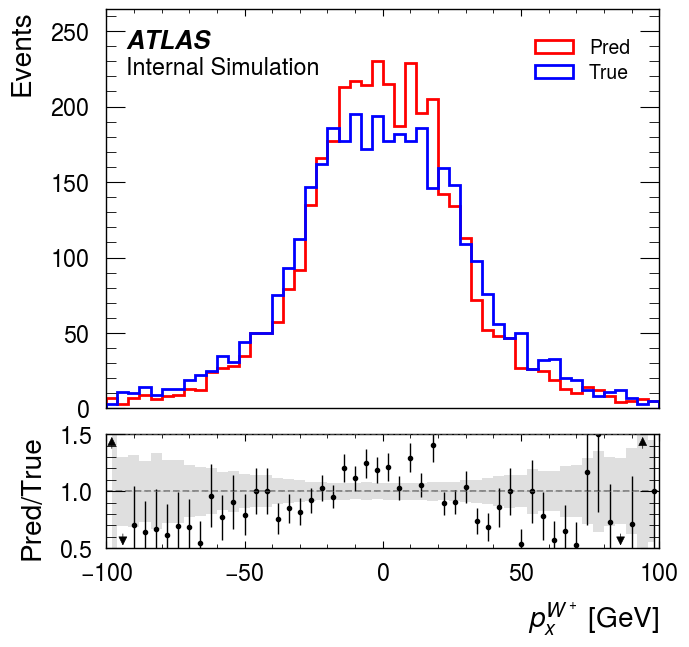

Rel err < 20%: 26.19 %


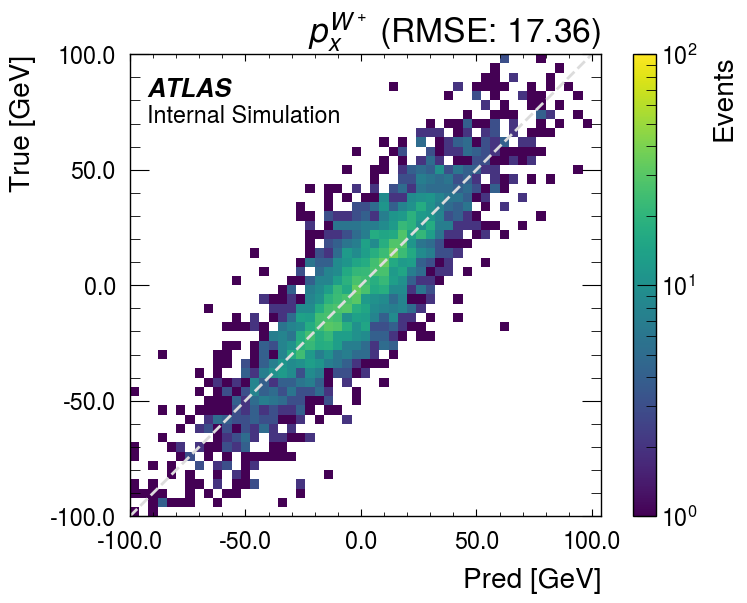

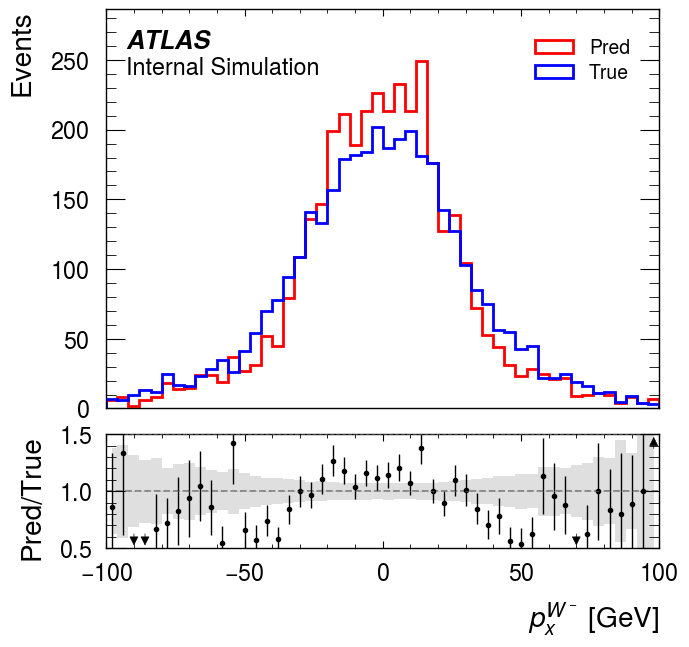

Rel err < 20%: 23.19 %


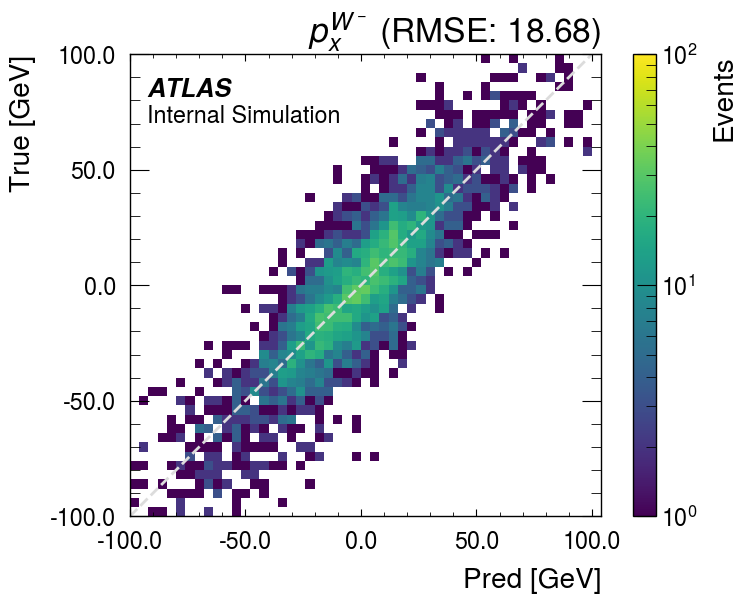

In [28]:
bins = np.linspace(-100, 100, 51)
plot_1d_hist(pred_w0_px, true_w0_px, bins_edges=bins, name=r"$p_x^{W^+}$")
plot_2d_hist(pred_w0_px, true_w0_px, name=r"$p_x^{W^+}$", bins_edges=bins, log=True)
plot_1d_hist(pred_w1_px, true_w1_px, bins_edges=bins, name=r"$p_x^{W^-}$")
plot_2d_hist(pred_w1_px, true_w1_px, name=r"$p_x^{W^-}$", bins_edges=bins, log=True)

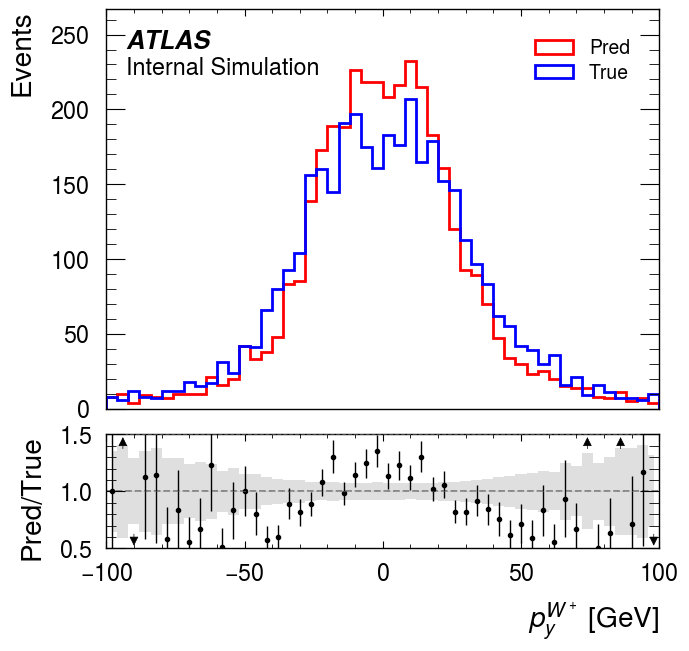

Rel err < 20%: 25.18 %


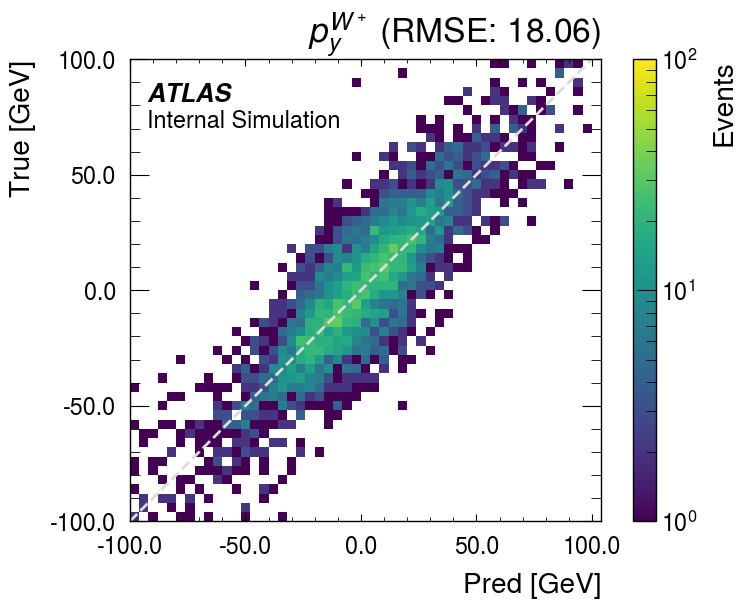

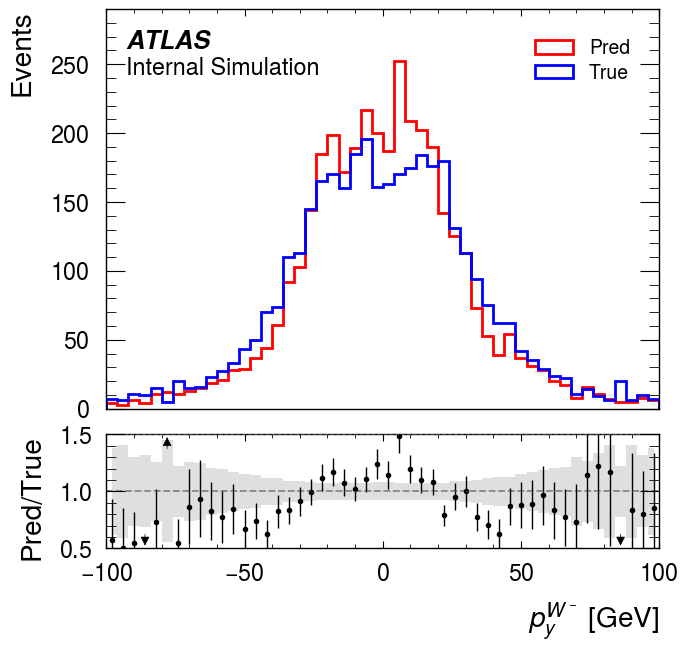

Rel err < 20%: 27.33 %


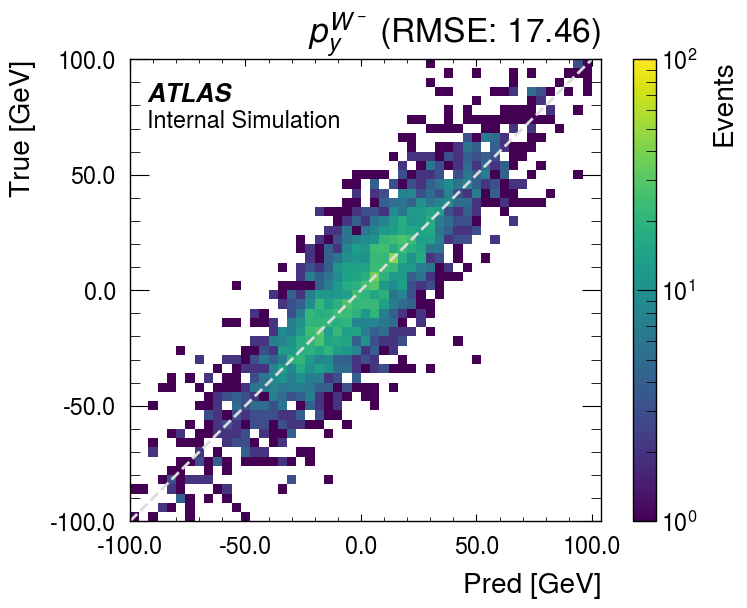

In [29]:
bins = np.linspace(-100, 100, 51)
plot_1d_hist(pred_w0_py, true_w0_py, bins_edges=bins, name=r"$p_y^{W^+}$")
plot_2d_hist(pred_w0_py, true_w0_py, name=r"$p_y^{W^+}$", bins_edges=bins, log=True)
plot_1d_hist(pred_w1_py, true_w1_py, bins_edges=bins, name=r"$p_y^{W^-}$")
plot_2d_hist(pred_w1_py, true_w1_py, name=r"$p_y^{W^-}$", bins_edges=bins, log=True)

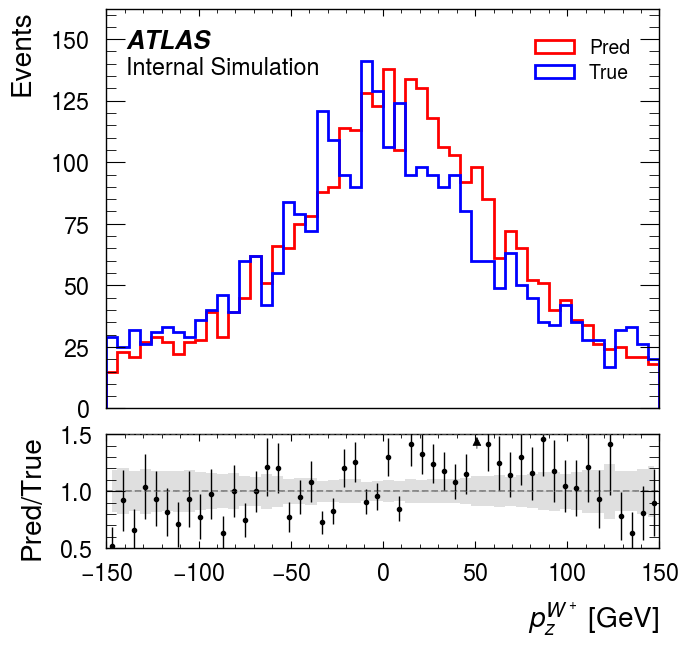

Rel err < 20%: 29.29 %


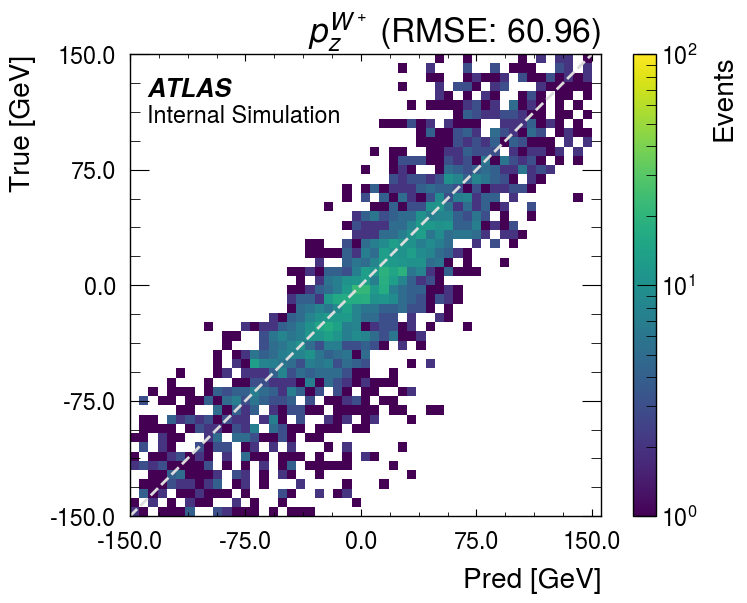

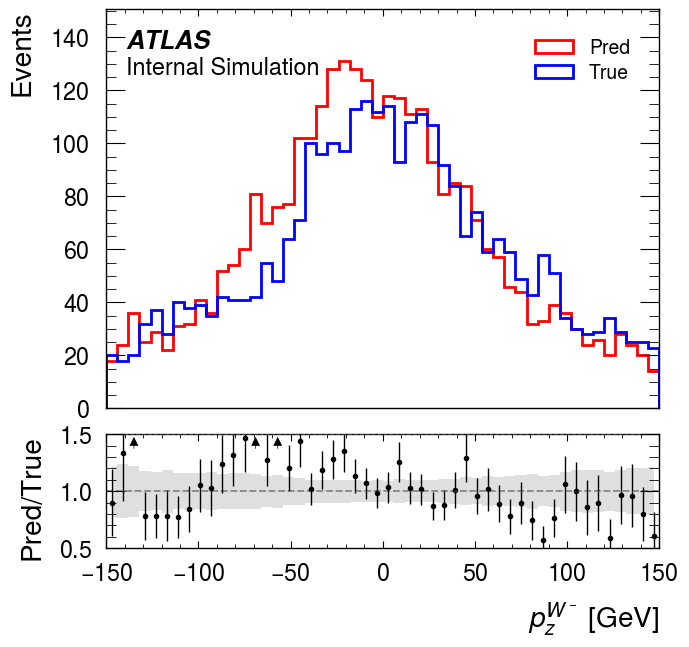

Rel err < 20%: 28.23 %


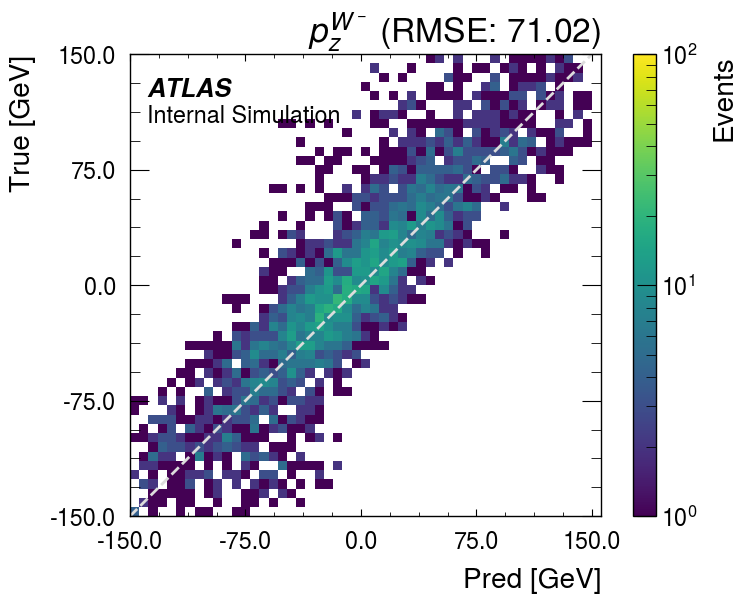

In [30]:
bins = np.linspace(-150, 150, 51)
plot_1d_hist(pred_w0_pz, true_w0_pz, bins_edges=bins, name=r"$p_z^{W^+}$")
plot_2d_hist(pred_w0_pz, true_w0_pz, name=r"$p_z^{W^+}$", bins_edges=bins, log=True)
plot_1d_hist(pred_w1_pz, true_w1_pz, bins_edges=bins, name=r"$p_z^{W^-}$")
plot_2d_hist(pred_w1_pz, true_w1_pz, name=r"$p_z^{W^-}$", bins_edges=bins, log=True)

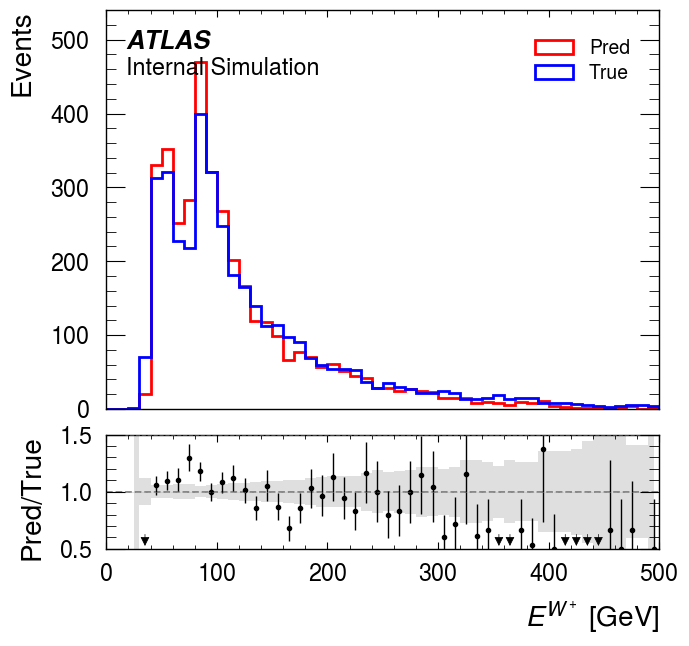

Rel err < 20%: 58.69 %


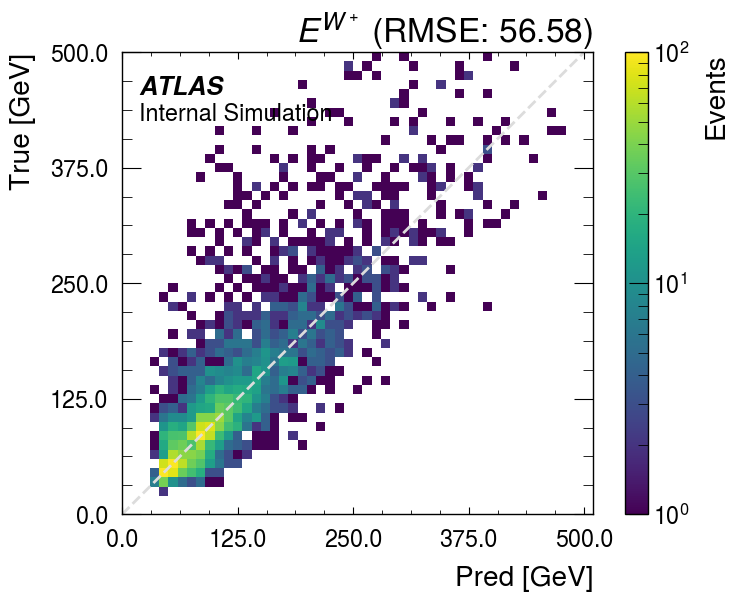

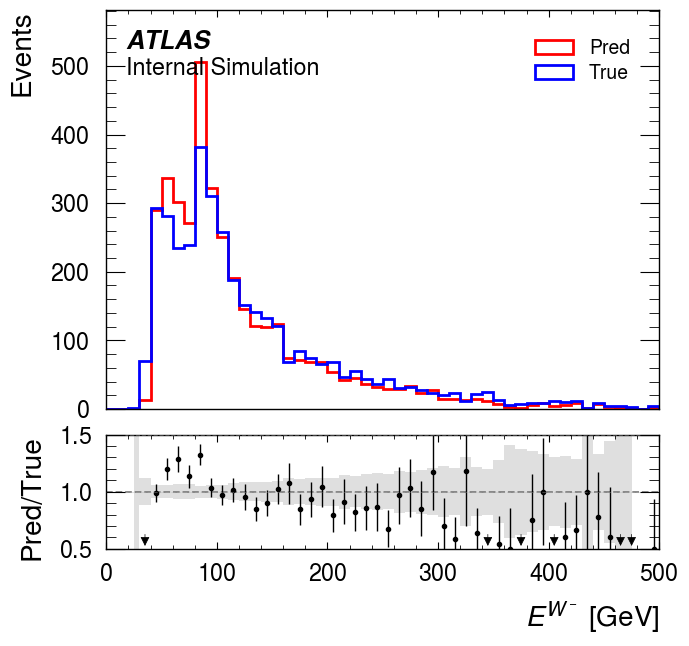

Rel err < 20%: 58.13 %


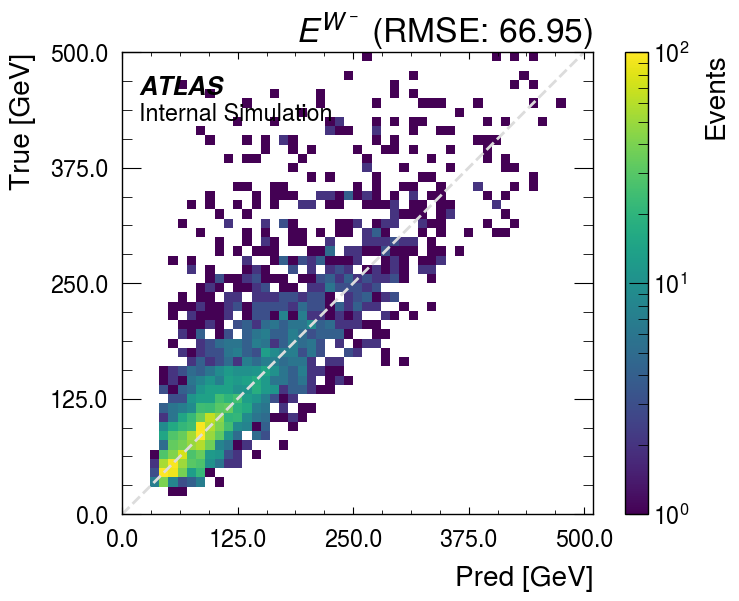

In [31]:
bins = np.linspace(0, 500, 51)
plot_1d_hist(pred_w0_energy, true_w0_energy, bins_edges=bins, name=r"$E^{W^+}$")
plot_2d_hist(pred_w0_energy, true_w0_energy, name=r"$E^{W^+}$", bins_edges=bins, log=True, color="black")
plot_1d_hist(pred_w1_energy, true_w1_energy, bins_edges=bins, name=r"$E^{W^-}$")
plot_2d_hist(pred_w1_energy, true_w1_energy, name=r"$E^{W^-}$", bins_edges=bins, log=True, color="black")

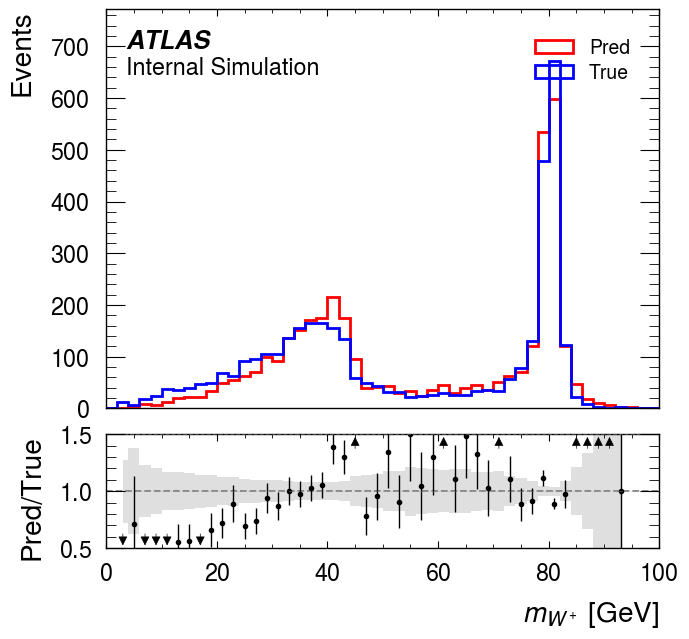

Rel err < 20%: 56.75 %


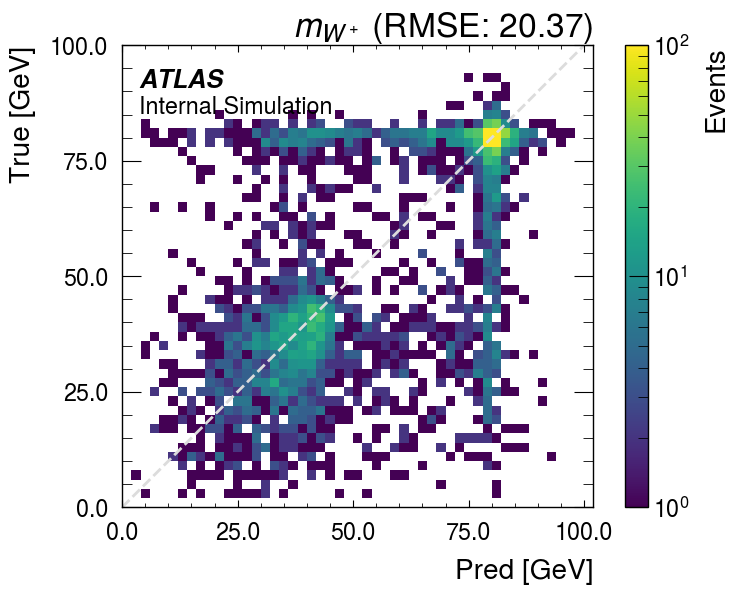

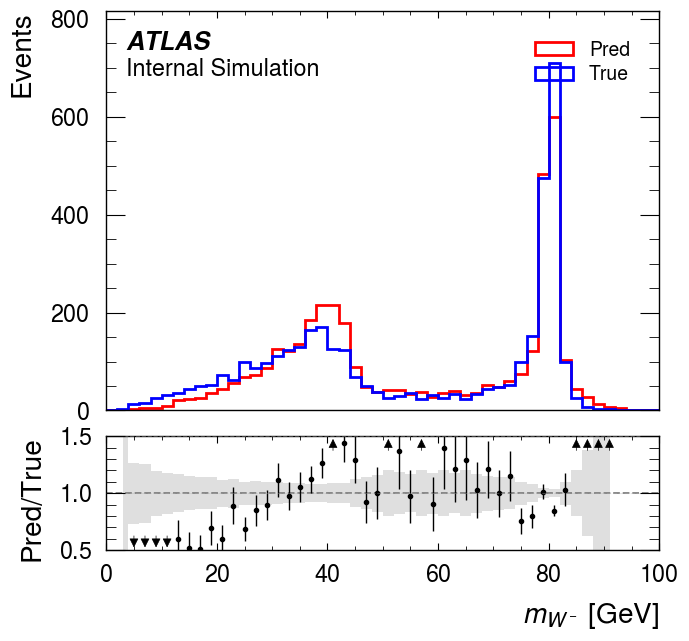

Rel err < 20%: 56.43 %


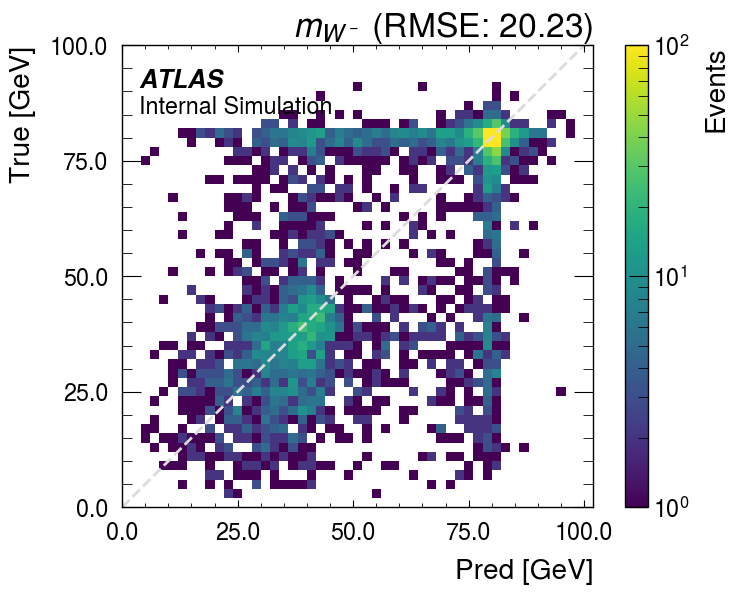

In [32]:
bins = np.linspace(0, 100, 51)
plot_1d_hist(np.sqrt(pred_w0_mass_2), np.sqrt(true_w0_mass_2), bins_edges=bins, name=r"$m_{W^+}$", unit="GeV")
plot_2d_hist(np.sqrt(pred_w0_mass_2), np.sqrt(true_w0_mass_2), name=r"$m_{W^+}$", bins_edges=bins, log=True, unit="GeV")
plot_1d_hist(np.sqrt(pred_w1_mass_2), np.sqrt(true_w1_mass_2), bins_edges=bins, name=r"$m_{W^-}$", unit="GeV")
plot_2d_hist(np.sqrt(pred_w1_mass_2), np.sqrt(true_w1_mass_2), name=r"$m_{W^-}$", bins_edges=bins, log=True, unit="GeV")

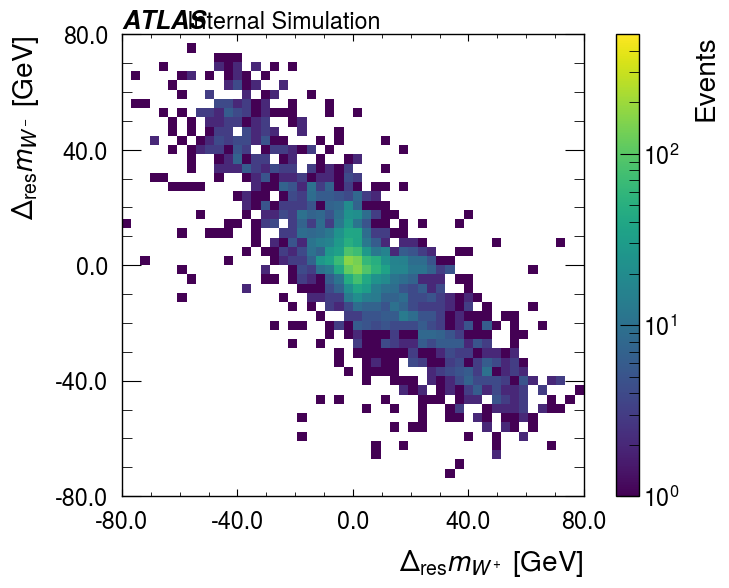

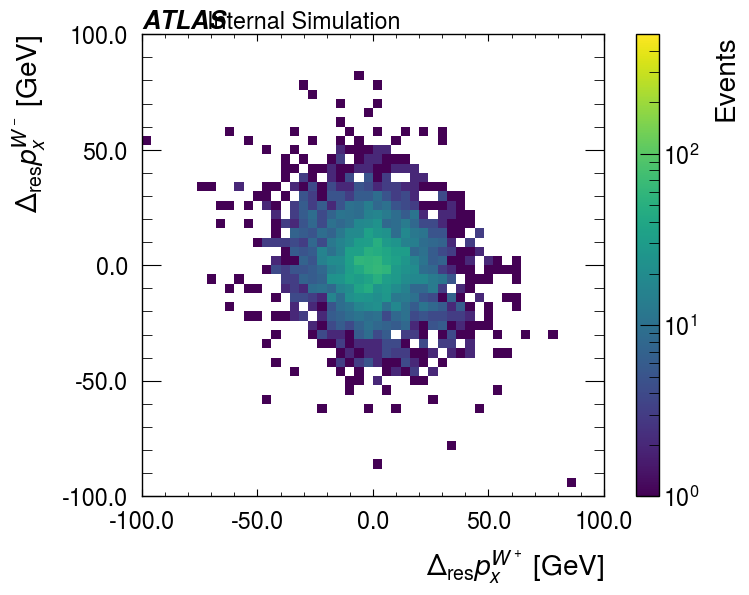

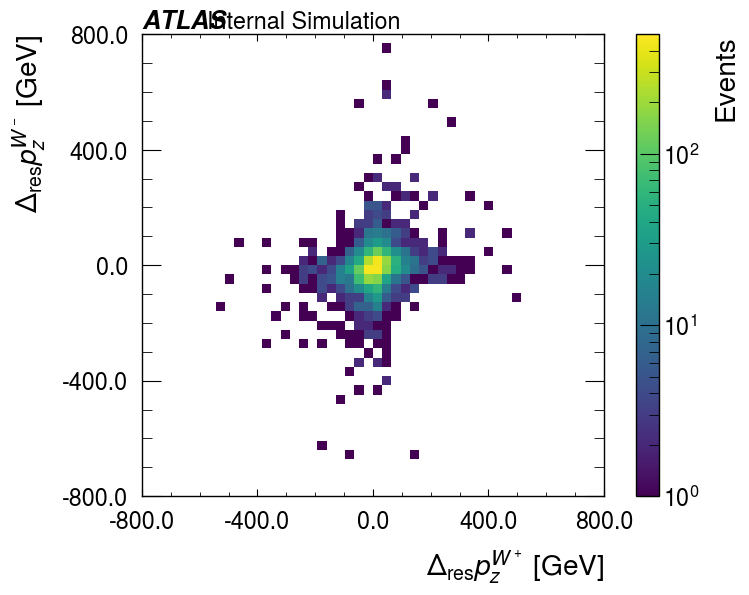

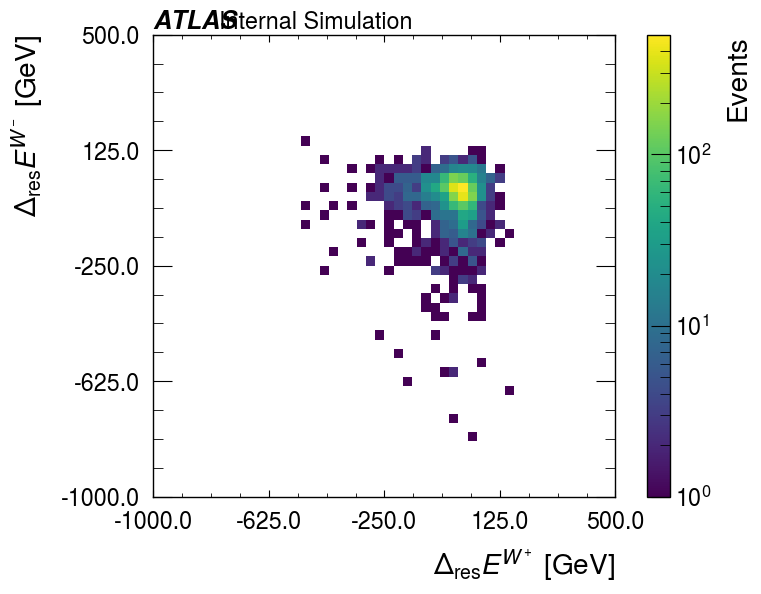

In [33]:
w0_mass_res = np.sqrt(pred_w0_mass_2) - np.sqrt(true_w0_mass_2)
w1_res = np.sqrt(pred_w1_mass_2) - np.sqrt(true_w1_mass_2)
plot_2d_res_hist(w0_mass_res, w1_res, name_pos=r"$m_{W^+}$", name_neg=r"$m_{W^-}$", bins_edges=np.linspace(-80, 80, 51), log=True, unit="GeV", color="black", vmax=5e2)

w0_px_res = pred_w0_px - true_w0_px
w1_px_res = pred_w1_px - true_w1_px
plot_2d_res_hist(w0_px_res, w1_px_res, name_pos=r"$p_x^{W^+}$", name_neg=r"$p_x^{W^-}$", bins_edges=np.linspace(-100, 100, 51), log=True, unit="GeV", color="black", vmax=5e2)

w0_pz_res = pred_w0_pz - true_w0_pz
w1_pz_res = pred_w1_pz - true_w1_pz
plot_2d_res_hist(w0_pz_res, w1_pz_res, name_pos=r"$p_z^{W^+}$", name_neg=r"$p_z^{W^-}$", bins_edges=np.linspace(-800, 800, 51), log=True, unit="GeV", color="black", vmax=5e2)

w0_energy_res = pred_w0_energy - true_w0_energy
w1_energy_res = pred_w1_energy - true_w1_energy
plot_2d_res_hist(w0_energy_res, w1_energy_res, name_pos=r"$E^{W^+}$", name_neg=r"$E^{W^-}$", bins_edges=np.linspace(-1000, 500, 51), log=True, unit="GeV", color="black", vmax=5e2)

In [34]:
def alpha_func(lep_on_p4, neu_on_p4, lep_off_p4, neu_off_p4):
    
    def _cal_mass(p4):
        return np.sqrt(p4[:, 3]**2 - p4[:, 0]**2 - p4[:, 1]**2 - p4[:, 2]**2)
    
    def _cal_norm(p4):
        return np.sqrt(p4[:, 0]**2 + p4[:, 1]**2 + p4[:, 2]**2)
    
    # dinu_p4 = neu_on_p4 + neu_off_p4
    # dinu_mass = _cal_mass(dinu_p4)
    dinu_lep_on_p4 = lep_on_p4 + neu_on_p4 + neu_off_p4
    dinu_lep_on_mass = _cal_mass(dinu_lep_on_p4)
    dinu_lep_off_p4 = lep_off_p4 + neu_on_p4 + neu_off_p4
    dinu_lep_off_mass = _cal_mass(dinu_lep_off_p4)
        
    alpha = np.where(
        dinu_lep_on_mass > dinu_lep_off_mass,
        _cal_norm(neu_on_p4) / (_cal_norm(neu_on_p4) + _cal_norm(neu_off_p4) + 1e-16),
        _cal_norm(neu_off_p4) / (_cal_norm(neu_on_p4) + _cal_norm(neu_off_p4) + 1e-16)
    )
    
    return alpha

# true
true_w0_p4 = np.stack([true_w0_px, true_w0_py, true_w0_pz, true_w0_energy], axis=-1)
true_w1_p4 = np.stack([true_w1_px, true_w1_py, true_w1_pz, true_w1_energy], axis=-1)
true_lep0_p4 = np.stack([true_lep0_px, true_lep0_py, true_lep0_pz, true_lep0_energy], axis=-1)
true_lep1_p4 = np.stack([true_lep1_px, true_lep1_py, true_lep1_pz, true_lep1_energy], axis=-1)

# pred
pred_w0_p4 = np.stack([pred_w0_px, pred_w0_py, pred_w0_pz, pred_w0_energy], axis=-1)
pred_w1_p4 = np.stack([pred_w1_px, pred_w1_py, pred_w1_pz, pred_w1_energy], axis=-1)

w_mass_con = 80.379 # GeV
w_mass_con_2 = w_mass_con ** 2

true_0_on_mask = np.abs(true_w0_mass_2 - w_mass_con_2) < np.abs(true_w1_mass_2 - w_mass_con_2)
true_lep_on_p4 = np.where(true_0_on_mask[:, np.newaxis], true_lep0_p4, true_lep1_p4)
true_lep_off_p4 = np.where(true_0_on_mask[:, np.newaxis], true_lep1_p4, true_lep0_p4)
true_w_on_p4 = np.where(true_0_on_mask[:, np.newaxis], true_w0_p4, true_w1_p4)
true_w_off_p4 = np.where(true_0_on_mask[:, np.newaxis], true_w1_p4, true_w0_p4)
true_neu_on_p4 = true_w_on_p4 - true_lep_on_p4
true_neu_off_p4 = true_w_off_p4 - true_lep_off_p4

pred_0_on_mask = np.abs(pred_w0_mass_2 - w_mass_con_2) < np.abs(pred_w1_mass_2 - w_mass_con_2)
pred_w_on_p4 = np.where(pred_0_on_mask[:, np.newaxis], pred_w0_p4, pred_w1_p4)
pred_w_off_p4 = np.where(pred_0_on_mask[:, np.newaxis], pred_w1_p4, pred_w0_p4)
pred_neu_on_p4 = pred_w_on_p4 - true_lep_on_p4
pred_neu_off_p4 = pred_w_off_p4 - true_lep_off_p4

true_alpha = alpha_func(true_lep_on_p4, true_neu_on_p4, true_lep_off_p4, true_neu_off_p4)
pred_alpha = alpha_func(true_lep_on_p4, pred_neu_on_p4, true_lep_off_p4, pred_neu_off_p4)

/tmp/ipykernel_335748/4229498418.py:4: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(p4[:, 3]**2 - p4[:, 0]**2 - p4[:, 1]**2 - p4[:, 2]**2)


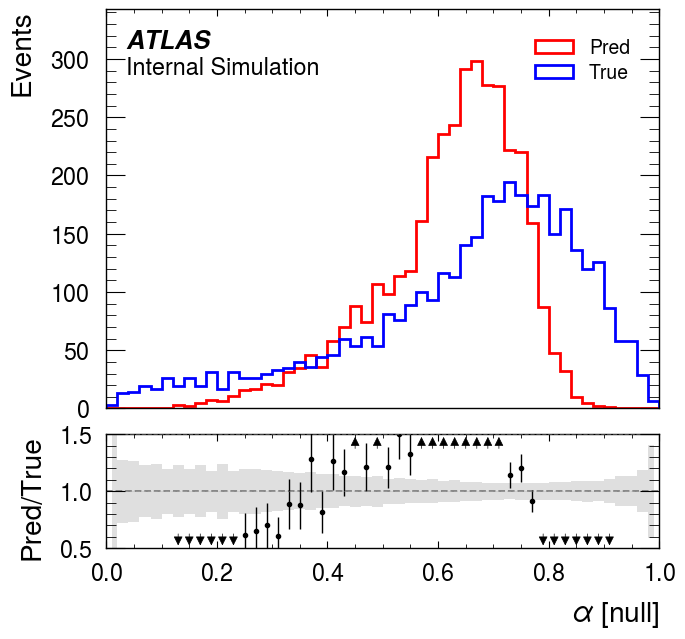

Rel err < 20%: 50.46 %


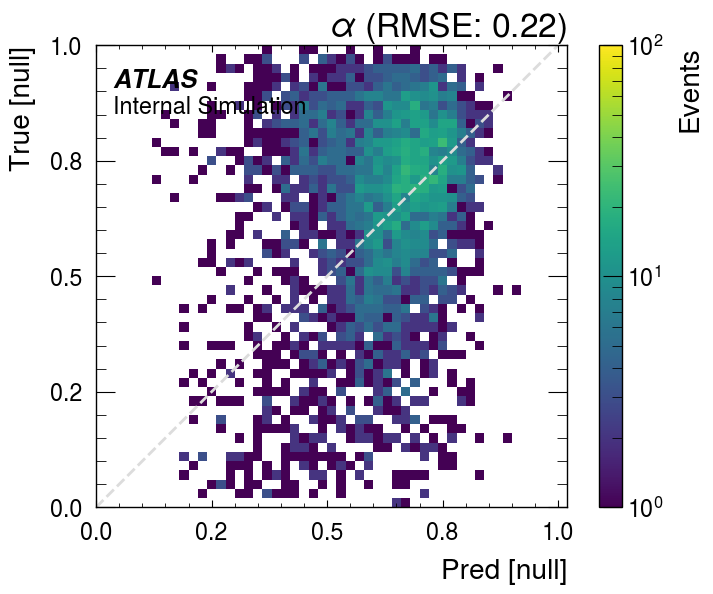

In [35]:
plot_1d_hist(pred_alpha, true_alpha, r"$\alpha$", np.linspace(0, 1, 51), unit="null")
plot_2d_hist(pred_alpha, true_alpha, r"$\alpha$", np.linspace(0, 1, 51), log=True, unit="null", color="black", vmax=1e2)

In [36]:
from ohbboosting import Booster

true_w0_p4 = np.stack([true_w0_px, true_w0_py, true_w0_pz, true_w0_energy], axis=1)
true_l0_p4 = np.stack([true_lep0_px,true_lep0_py,true_lep0_pz,true_lep0_energy], axis=1)
true_w1_p4 = np.stack([true_w1_px, true_w1_py, true_w1_pz, true_w1_energy], axis=1)
true_l1_p4 = np.stack([true_lep1_px,true_lep1_py,true_lep1_pz,true_lep1_energy], axis=1)

particles = np.concatenate(
	[
		true_w0_p4,
		true_l0_p4,
		true_w1_p4,
		true_l1_p4,
	],
	axis=-1,
)
booster = Booster(particles)
booster.setup()
print(particles.shape)
true_l0_theta_phi, true_l1_theta_phi = booster.lep_theta_phi_in_w_rest()
# true_xi_pos, true_xi_neg = booster.lep_xi_in_w_rest()
# true_cglmp_bij = booster.cglmp_bij()

Make sure the input particles are ordered as [W+, l+, W-, l-]!
Booster setup completed.
(3769, 16)


In [37]:
pred_w0_p4 = np.stack([pred_w0_px, pred_w0_py, pred_w0_pz, pred_w0_energy], axis=1)
pred_w1_p4 = np.stack([pred_w1_px, pred_w1_py, pred_w1_pz, pred_w1_energy], axis=1)

particles = np.concatenate(
	[
		pred_w0_p4,
		true_l0_p4, # we can measure lepton 4-momentum precisely
		pred_w1_p4,
		true_l1_p4,
	],
	axis=-1,
)
booster = Booster(particles)
booster.setup()
print(particles.shape)
pred_l0_theta_phi, pred_l1_theta_phi = booster.lep_theta_phi_in_w_rest()
# pred_xi_pos, pred_xi_neg = booster.lep_xi_in_w_rest()
# pred_cglmp_bij = booster.cglmp_bij()

Make sure the input particles are ordered as [W+, l+, W-, l-]!
Booster setup completed.
(3769, 16)


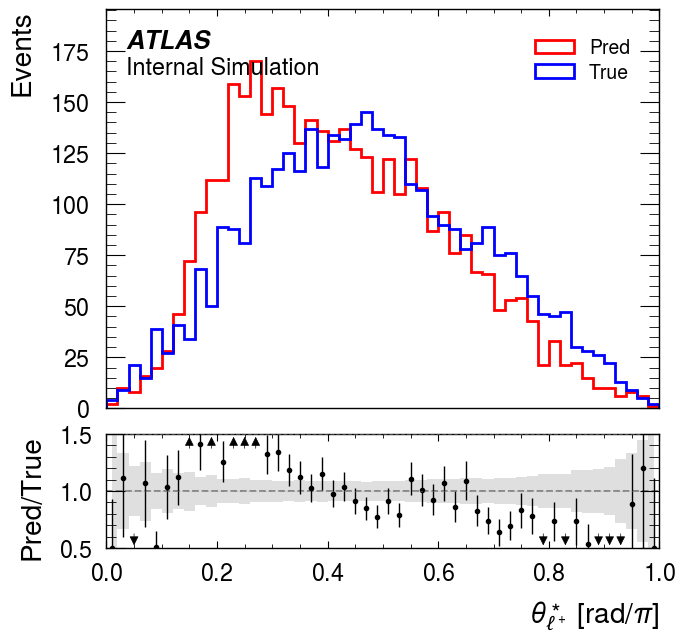

Rel err < 20%: 36.69 %


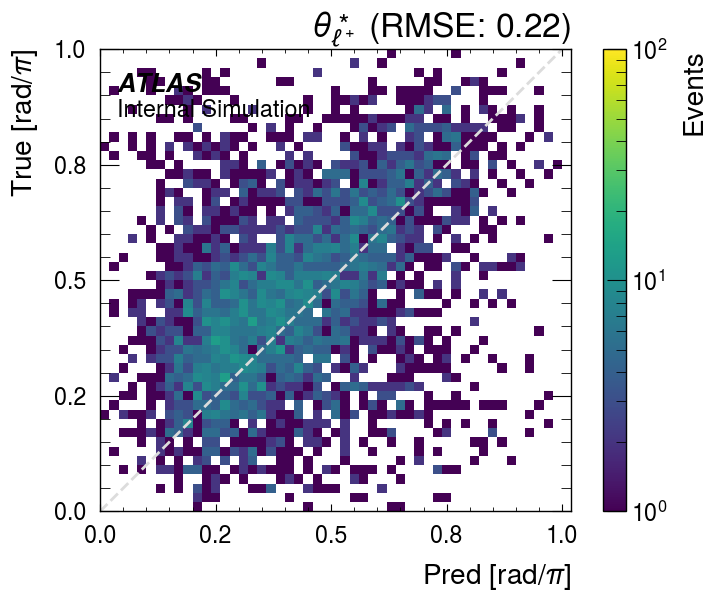

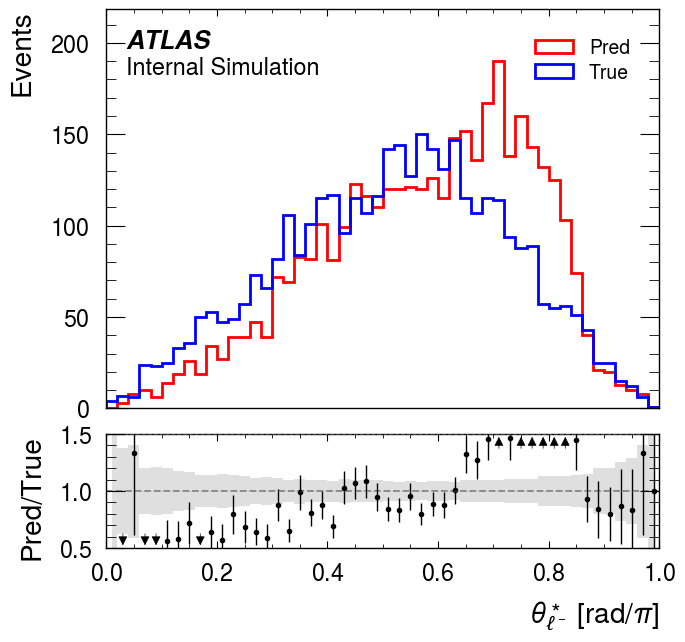

Rel err < 20%: 42.85 %


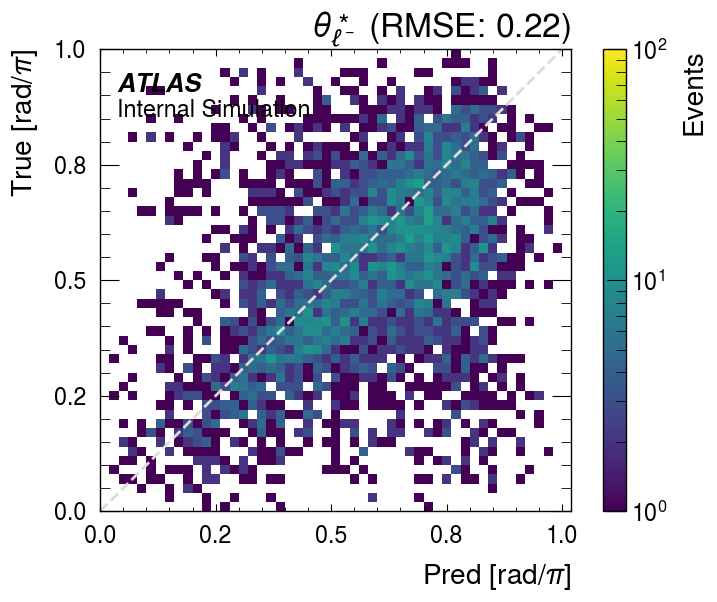

In [38]:
plot_1d_hist(pred_l0_theta_phi[0], true_l0_theta_phi[0], r"$\theta^\ast_{\ell^+}$", np.linspace(0, 1, 51), unit="rad/$\pi$")
plot_2d_hist(pred_l0_theta_phi[0], true_l0_theta_phi[0], r"$\theta^\ast_{\ell^+}$", np.linspace(0, 1, 51), log=True, unit="rad/$\pi$", color="black", vmax=1e2)
plot_1d_hist(pred_l1_theta_phi[0], true_l1_theta_phi[0], r"$\theta^\ast_{\ell^-}$", np.linspace(0, 1, 51), unit="rad/$\pi$")
plot_2d_hist(pred_l1_theta_phi[0], true_l1_theta_phi[0], r"$\theta^\ast_{\ell^-}$", np.linspace(0, 1, 51), log=True, unit="rad/$\pi$", color="black", vmax=1e2)

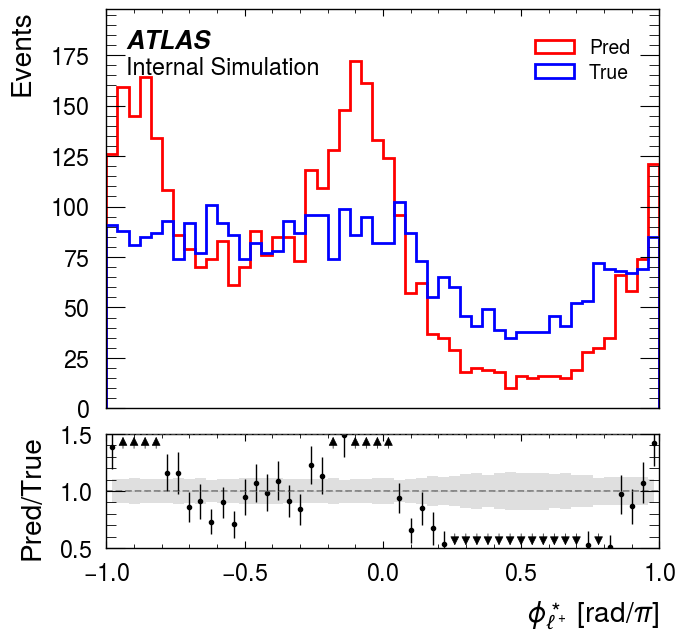

Rel err < 20%: 18.49 %


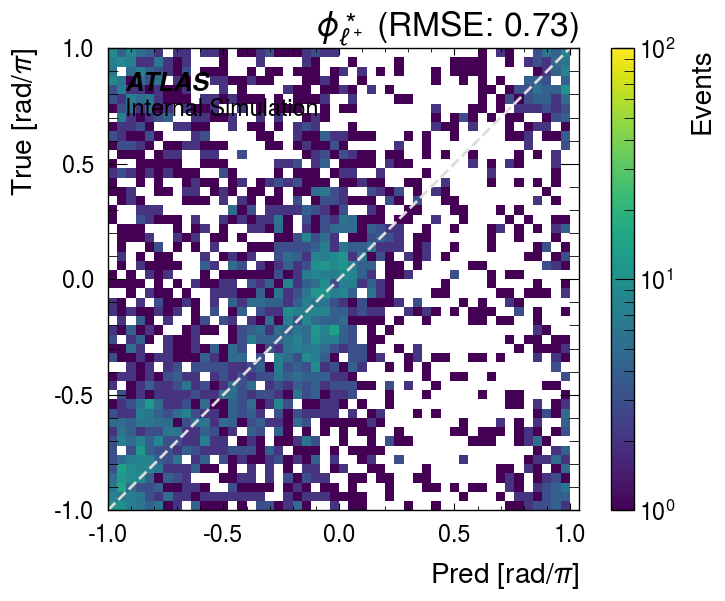

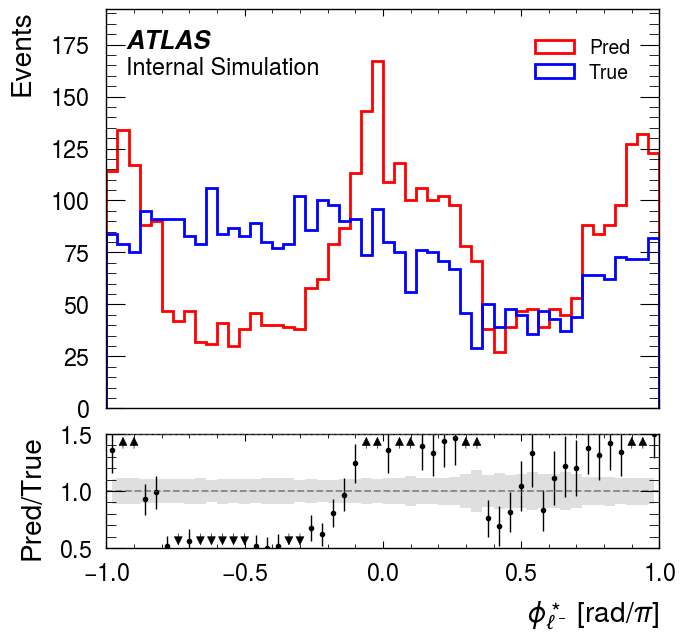

Rel err < 20%: 18.52 %


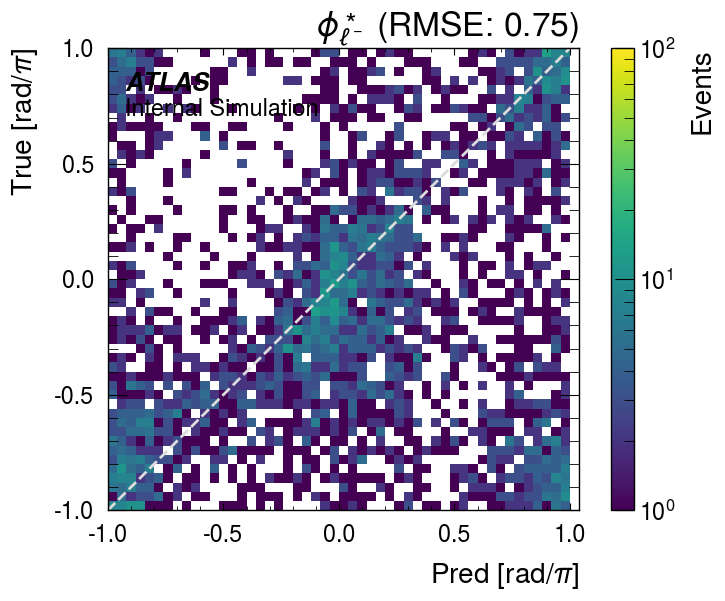

In [39]:
plot_1d_hist(pred_l0_theta_phi[1], true_l0_theta_phi[1], r"$\phi^\ast_{\ell^+}$", np.linspace(-1, 1, 51), unit="rad/$\pi$")
plot_2d_hist(pred_l0_theta_phi[1], true_l0_theta_phi[1], r"$\phi^\ast_{\ell^+}$", np.linspace(-1, 1, 51), log=True, unit="rad/$\pi$", color="black", vmax=1e2)
plot_1d_hist(pred_l1_theta_phi[1], true_l1_theta_phi[1], r"$\phi^\ast_{\ell^-}$", np.linspace(-1, 1, 51), unit="rad/$\pi$")
plot_2d_hist(pred_l1_theta_phi[1], true_l1_theta_phi[1], r"$\phi^\ast_{\ell^-}$", np.linspace(-1, 1, 51), log=True, unit="rad/$\pi$", color="black", vmax=1e2)

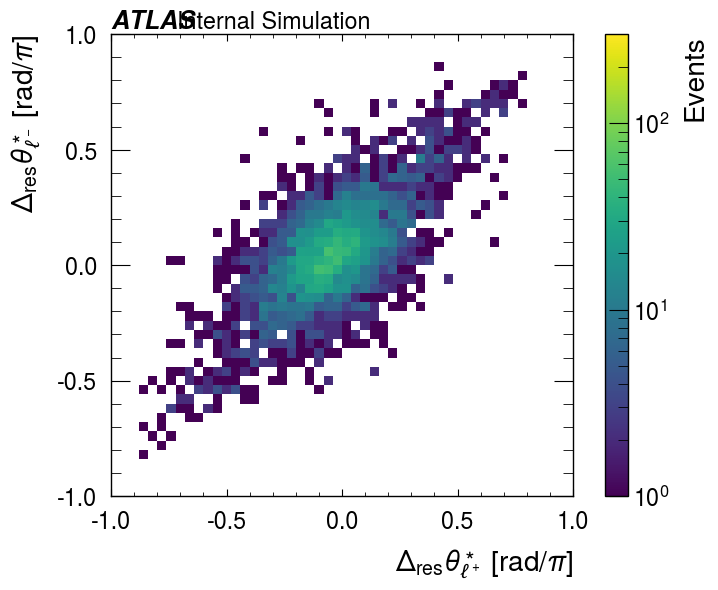

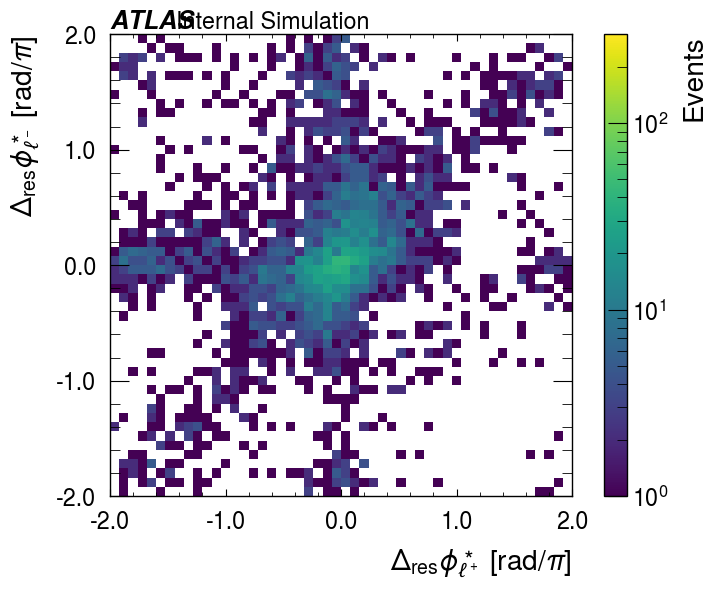

In [40]:
l0_theta_res = pred_l0_theta_phi[0] - true_l0_theta_phi[0]
l1_theta_res = pred_l1_theta_phi[0] - true_l1_theta_phi[0]
plot_2d_res_hist(l0_theta_res, l1_theta_res, name_pos=r"$\theta^\ast_{\ell^+}$", name_neg=r"$\theta^\ast_{\ell^-}$", bins_edges=np.linspace(-1, 1, 51), log=True, unit="rad/$\pi$", color="black", vmax=3e2)

l0_phi_res = pred_l0_theta_phi[1] - true_l0_theta_phi[1]
l1_phi_res = pred_l1_theta_phi[1] - true_l1_theta_phi[1]
plot_2d_res_hist(l0_phi_res, l1_phi_res, name_pos=r"$\phi^\ast_{\ell^+}$", name_neg=r"$\phi^\ast_{\ell^-}$", bins_edges=np.linspace(-2, 2, 51), log=True, unit="rad/$\pi$", color="black", vmax=3e2)

Found log directories: ['./hww_pcres_regressor_nofold/logs/version_0/']


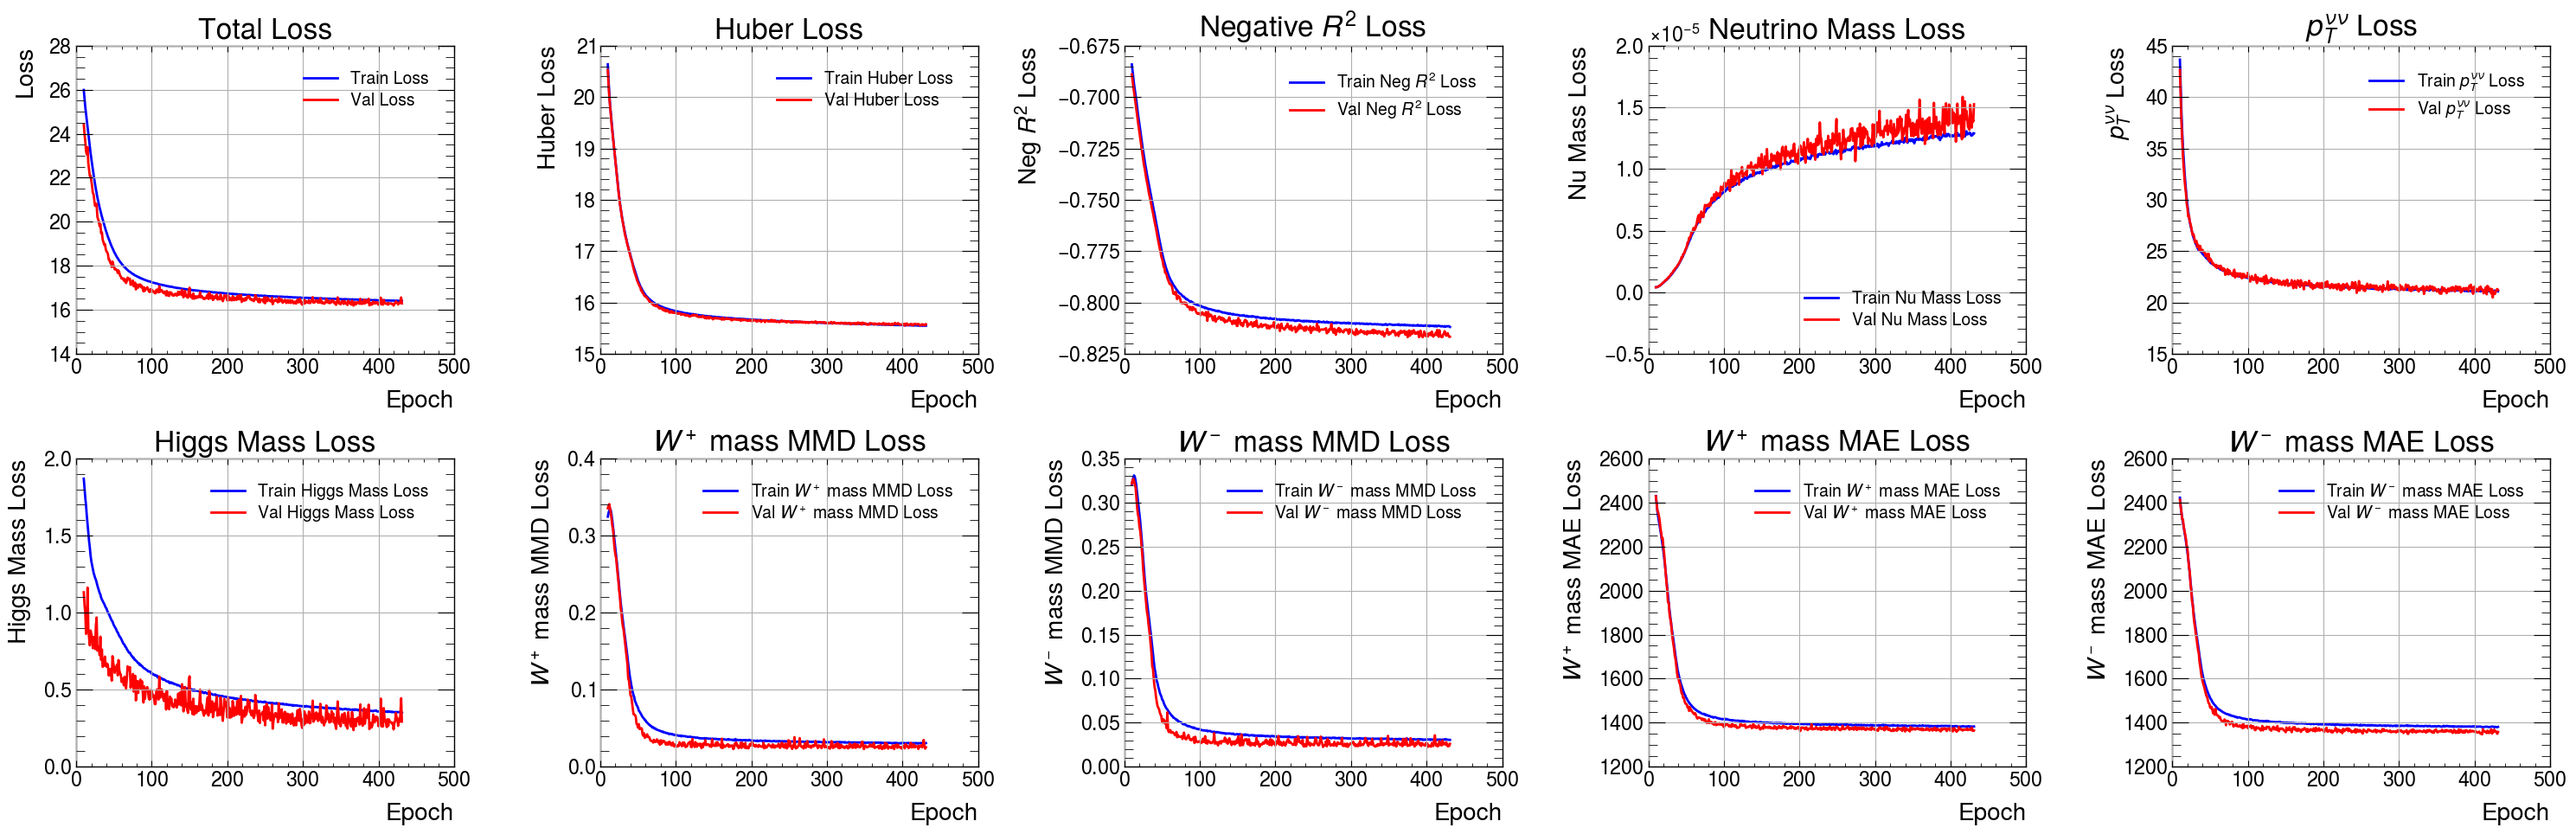

Final Training Losses (Epoch 431):
  Total Loss: 16.402870
  Huber Loss: 15.547239
  Negative $R^2$ Loss: -0.811902
  Neutrino Mass Loss: 0.000013
  $p^{\nu\nu}_T$ Loss: 21.078058
  Higgs Mass Loss: 0.351358
  $W^+$ mass MMD Loss: 0.030666
  $W^-$ mass MMD Loss: 0.030500
  $W^+$ mass MAE Loss: 1383.051880
  $W^-$ mass MAE Loss: 1381.179932
  $W^+$ mom MMD Loss: 0.019565
  $W^-$ mom MMD Loss: 0.019467
Final Validation Losses:
  Total Loss: 16.289345
  Huber Loss: 15.575697
  Negative $R^2$ Loss: -0.816664
  Neutrino Mass Loss: 0.000015
  $p^{\nu\nu}_T$ Loss: 21.214876
  Higgs Mass Loss: 0.292928
  $W^+$ mass MMD Loss: 0.025106
  $W^-$ mass MMD Loss: 0.026010
  $W^+$ mass MAE Loss: 1364.545532
  $W^-$ mass MAE Loss: 1357.870728
  $W^+$ mom MMD Loss: 0.018591
  $W^-$ mom MMD Loss: 0.017829


In [41]:
log_dirs = glob.glob(f"./hww_pcres_regressor_nofold/logs/version_0/")
print(f"Found log directories: {log_dirs}")
if not log_dirs:
    print("No logs found.")
else:
    metrics_path = os.path.join(log_dirs[0], "metrics.csv")
    if not os.path.exists(metrics_path):
        print(f"No metrics.csv found in {log_dirs[0]}")
    else:
        df = pd.read_csv(metrics_path)
        df_clean = df.copy()
        df_clean_train = (
            df_clean[df_clean["loss"].notna()] if "loss" in df_clean.columns else pd.DataFrame()
        )
        df_clean_val = (
            df_clean[df_clean["val_loss"].notna()] if "val_loss" in df_clean.columns else pd.DataFrame()
        )

        if df_clean_train.empty or df_clean_val.empty:
            print("Not enough training or validation records to visualize.")
        else:
            fig, axes = plt.subplots(2, 5, figsize=(30, 10))
            axes = axes.flatten()

            plot_configs = [
                ("loss", "val_loss", "Total Loss", "Loss"),
                ("huber_loss", "val_huber_loss", "Huber Loss", "Huber Loss"),
                ("neg_r2_loss", "val_neg_r2_loss", "Negative $R^2$ Loss", "Neg $R^2$ Loss"),
                ("nu_mass_loss", "val_nu_mass_loss", "Neutrino Mass Loss", "Nu Mass Loss"),
                ("dinu_pt_loss", "val_dinu_pt_loss", r"$p^{\nu\nu}_T$ Loss", r"$p^{\nu\nu}_T$ Loss"),
                ("higgs_mass_loss", "val_higgs_mass_loss", "Higgs Mass Loss", "Higgs Mass Loss"),
                ("w_mass_mmd0_loss", "val_w_mass_mmd0_loss", "$W^+$ mass MMD Loss", "$W^+$ mass MMD Loss"),
                ("w_mass_mmd1_loss", "val_w_mass_mmd1_loss", "$W^-$ mass MMD Loss", "$W^-$ mass MMD Loss"),
                ("w0_mass_mae_loss", "val_w0_mass_mae_loss", "$W^+$ mass MAE Loss", "$W^+$ mass MAE Loss"),
                ("w1_mass_mae_loss", "val_w1_mass_mae_loss", "$W^-$ mass MAE Loss", "$W^-$ mass MAE Loss"),
                ("aux_mom_mmd0_loss", "val_aux_mom_mmd0_loss", "$W^+$ mom MMD Loss", "$W^+$ mom MMD Loss"),
                ("aux_mom_mmd1_loss", "val_aux_mom_mmd1_loss", "$W^-$ mom MMD Loss", "$W^-$ mom MMD Loss"),
            ]

            def apply_scale(ax, data):
                finite = data.replace([np.inf, -np.inf], np.nan).dropna()
                if finite.empty:
                    return
                if (finite <= 0).any():
                    ax.set_yscale("symlog", linthresh=1e-3)
                else:
                    ax.set_yscale("log")

            epochs_train = df_clean_train["epoch"].iloc[10:]
            epochs_val = df_clean_val["epoch"].iloc[10:]

            for ax, (train_col, val_col, title, ylabel) in zip(axes, plot_configs):
                if train_col not in df_clean_train.columns or val_col not in df_clean_val.columns:
                    ax.set_visible(False)
                    continue

                ax.plot(epochs_train, df_clean_train[train_col].iloc[10:], label=f"Train {ylabel}", color="blue")
                ax.plot(epochs_val, df_clean_val[val_col].iloc[10:], label=f"Val {ylabel}", color="red")
                ax.set_xlabel("Epoch")
                ax.set_ylabel(ylabel)
                ax.set_title(title)
                ax.legend()
                ax.grid(True)
                # apply_scale(ax, pd.concat([df_clean_train[train_col], df_clean_val[val_col]]))

            plt.tight_layout()
            plt.show()

            last_epoch = df_clean_train["epoch"].iloc[-1]
            print(f"Final Training Losses (Epoch {last_epoch}):")
            for train_col, _, title, _ in plot_configs:
                if train_col in df_clean_train.columns:
                    print(f"  {title}: {df_clean_train[train_col].iloc[-1]:.6f}")

            print("Final Validation Losses:")
            for _, val_col, title, _ in plot_configs:
                if val_col in df_clean_val.columns:
                    print(f"  {title}: {df_clean_val[val_col].iloc[-1]:.6f}")

In [42]:
# import shap
# import matplotlib as mpl

# mpl.rcParams.update(mpl.rcParamsDefault)

# # Use GradientExplainer with separate background and test samples
# background_sample = torch.tensor(train_features[0:256]).float().to(device)
# samples_to_explain = torch.tensor(train_features[512:512+1024]).float().to(device)
# explainer = shap.GradientExplainer(model, background_sample)
# shap_values = explainer.shap_values(samples_to_explain, nsamples=200)

# for i in range(shap_values.shape[-1]):
# 	fig = plt.figure(figsize=(10, 8))
# 	shap.summary_plot(
# 		shap_values[:, :, i],
# 		samples_to_explain.cpu().numpy(),
# 		# No feature_names - will use feature indices 0-71
# 		plot_type="dot",
# 		max_display=10,
# 		show=False,
# 	)
# 	plt.title(f"SHAP Summary Plot for Output {i}", fontsize=16)
# 	plt.tight_layout()
# 	plt.show()